## Ejercicio 1

Implemente las estructuras de datos y algoritmos básicos para la solución de un problema mediante algoritmos genéticos. Pruebe estas rutinas y compare los resultados con un método de gradiente descendiente para buscar el mínimo global de las siguientes funciones:

### Idea del algoritmo evolutivo

```mermaid
flowchart TD
    A["Población inicial<br/>aleatoria"] --> B["Evaluar aptitud<br/>= −f(x)"]
    B --> C{"¿Mejor aptitud<br/>≥ objetivo?"}
    C -- "Sí, o llegué al máximo<br/>de generaciones" --> Z(["Fin: mejor<br/>individuo"])
    C -- No --> D["Selección por torneo<br/>(k=2): padre y madre"]
    D --> E["Codificar a binario"]
    E --> F["Cruce en un punto"]
    F --> G["Mutación: prob.<br/>1/n_bits por bit"]
    G --> H["Decodificar a real<br/>→ hijo"]
    H --> I{"¿Hijos suficientes?"}
    I -- No --> D
    I -- Sí --> J["Reemplazo: generacional<br/>o elitista"]
    J --> B
```

- **Reemplazo:** el parámetro `reemplazo` es la fracción de la población que se reemplaza por hijos. Con `1` es **generacional** (toda la población nueva son hijos y el mejor se puede perder). Con un valor menor a 1 es **elitista**: con `0.9` y 20 individuos se conservan los 2 mejores y se generan 18 hijos.
- **Parada:** el algoritmo termina cuando el mejor alcanza la **aptitud objetivo** (418.98 en el inciso 1, 0 en el inciso 2) o cuando llega al máximo de generaciones.

| | Inciso 1 | Inciso 2 |
|---|---|---|
| Individuo | `x` real | `(x, y)` reales |
| Codificación | 20 bits, real en $[-512, 512]$ | 20 + 20 bits, reales en $[-100, 100]$ |
| Aptitud objetivo | $418.98$ | $0$ |


In [ ]:
import math
import random
import pandas as pd
import matplotlib.pyplot as plt

#cantidad de bits por variable y límites de cada variable según la actividad
BITS = 20
LIMITES = {1: [(-512, 512)], 2: [(-100, 100), (-100, 100)]}

#las 2 funciones a minimizar
def funcion(x, y = None):
    if y == None:
        return -x*math.sin(math.sqrt(abs(x))) #[-512, 512] minimo: -418.98
    else:
        return ((x**2 + y**2)**0.25)*(math.sin(50*((x**2 + y**2)**0.1))**2 + 1) #[-100,100] minimo = 0

#funcion que evalua la aptitud de la poblacion (como buscamos el minimo, aptitud = -f)
#algunas funciones reciben "actividad" para saber que hacer en cada actividad
def evaluar(poblacion, actividad):

    aptitudes = []

    for individuo in poblacion:

        if actividad == 1:
            aptitudes.append(-funcion(individuo))

        if actividad == 2:
            aptitudes.append(-funcion(individuo[0], individuo[1]))

        if actividad == 3:
            aptitudes.append(aptitud_genes(individuo))   #definida en el ejercicio 2

    return aptitudes


#funcion que elige a los 2 padres de la poblacion mediante torneo
def seleccion(poblacion, aptitudes, k = 2):
    idx_padres = []
    idx_madres = []

    for i in range(k):
        idx_padres.append(random.randrange(len(poblacion)))
        idx_madres.append(random.randrange(len(poblacion)))

    idx_padre = idx_padres[0]
    idx_madre = idx_madres[0]

    for i in range(k):
        if aptitudes[idx_padres[i]] > aptitudes[idx_padre]:
            idx_padre = idx_padres[i]

        if aptitudes[idx_madres[i]] > aptitudes[idx_madre]:
            idx_madre = idx_madres[i]

    return poblacion[idx_padre], poblacion[idx_madre]

#convierto el punto real a binario: cada variable se lleva de [a, b] a un entero entre 0 y 2^BITS - 1
#y se escribe con BITS bits. En actividad 1 es un numero (x), en actividad 2 una tupla (x, y): concateno los bits
def real_a_binario(z, actividad):
    if actividad == 1:
        valores = [z]
    else:
        valores = [z[0], z[1]]

    maximo = 2 ** BITS - 1
    bits = ''
    for i in range(len(valores)):
        a, b = LIMITES[actividad][i]
        entero = round((valores[i] - a) / (b - a) * maximo)
        bits = bits + format(entero, '0' + str(BITS) + 'b')
    return bits

#funcion que realiza el cruce de los padres para generar un hijo
def cruce(padre, madre):
    corte = random.randint(1, len(padre) - 1)
    hijo = padre[:corte] + madre[corte:]
    return hijo

#funcion que realiza la mutacion del hijo
def mutacion(hijo_binario, probabilidad):
    adn = list(hijo_binario)
    for i in range(len(adn)):
        if random.random() < probabilidad:
            if adn[i] == '1':
                adn[i] = '0'
            else:
                adn[i] = '1'
    hijo_mutado = ''.join(adn)
    return hijo_mutado

#convierto el binario a real: parto en grupos de BITS bits, paso cada grupo a entero y lo llevo a [a, b]
#x = a + entero * (b - a) / (2^BITS - 1)
def binario_a_real(bits, actividad):
    maximo = 2 ** BITS - 1
    valores = []
    for i in range(len(LIMITES[actividad])):
        a, b = LIMITES[actividad][i]
        entero = int(bits[i * BITS:(i + 1) * BITS], 2)
        valores.append(a + entero * (b - a) / maximo)

    if actividad == 1:
        return valores[0]
    return valores[0], valores[1]

#funcion que crea un hijo. La mutacion es 1/cantidad de bits: en promedio cambia 1 bit por hijo
def creacion(poblacion, aptitudes, actividad):
    padre, madre = seleccion(poblacion, aptitudes)
    if actividad == 3:
        hijo = cruce(padre, madre)
        hijo_mutado = mutacion(hijo, 1 / len(hijo))
        return hijo_mutado
    else:
        padre_binario = real_a_binario(padre, actividad)
        madre_binario = real_a_binario(madre, actividad)
        hijo_binario = cruce(padre_binario, madre_binario)
        hijo_mutado = mutacion(hijo_binario, 1 / len(hijo_binario))
        hijo = binario_a_real(hijo_mutado, actividad)
    return hijo

In [ ]:
def algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo, actividad, max_generaciones = 200):

    historia = []   #mejor aptitud de cada generacion, para graficar

    generacion = 1
    while True:

        #calculo las aptitudes de mi poblacion y encuentro el mejor, en este caso la aptitud maxima representa el minimo de la funcion
        aptitudes = evaluar(poblacion, actividad)
        mejorAptitud = max(aptitudes)
        mejor = poblacion[aptitudes.index(mejorAptitud)]
        historia.append(mejorAptitud)

        #termino si la mejor aptitud me sirve o si llegue al maximo de generaciones
        if mejorAptitud >= aptitudRequerida or generacion == max_generaciones:
            break

        #si no, creo una nueva poblacion
        hijos = []

        for i in range(round(len(poblacion) * reemplazo)):
            hijos.append(creacion(poblacion, aptitudes, actividad))

        if reemplazo == 1:  #reemplazo generacional
            poblacion = hijos

        else:  #reemplazo elitista

            indices = list(range(len(poblacion)))

            # ordeno los índices según la aptitud
            indices.sort(key=lambda i: aptitudes[i], reverse=True)

            cantidadConservar = len(poblacion) - len(hijos)

            mejores = []

            for i in range(cantidadConservar):
                mejores.append(poblacion[indices[i]])

            poblacion = mejores + hijos

        generacion = generacion + 1

    print("Generaciones:", generacion, "- mejor aptitud:", mejorAptitud)
    return mejor, mejorAptitud, historia

### Gradiente descendiente y gráficos

En cada paso se avanza en contra del gradiente: $p \leftarrow p - \eta \, \nabla f(p)$. El gradiente se aproxima numéricamente con diferencias centradas: $\frac{\partial f}{\partial x_i} \approx \frac{f(p + h\,e_i) - f(p - h\,e_i)}{2h}$.

In [ ]:
#evalua f en un punto guardado como lista: [x] o [x, y]
def f_punto(p):
    if len(p) == 1:
        return funcion(p[0])
    return funcion(p[0], p[1])

def gradiente_descendiente(inicio, actividad, tasa, iteraciones = 1000, h = 1e-6):
    p = list(inicio)
    camino = [list(p)]   #guardo el camino para graficarlo

    for it in range(iteraciones):
        #derivada parcial de cada variable por diferencias centradas
        gradiente = []
        for i in range(len(p)):
            adelante = list(p)
            atras = list(p)
            adelante[i] = adelante[i] + h
            atras[i] = atras[i] - h
            gradiente.append((f_punto(adelante) - f_punto(atras)) / (2 * h))

        #doy un paso en contra del gradiente sin salirme de los limites
        for i in range(len(p)):
            a, b = LIMITES[actividad][i]
            p[i] = p[i] - tasa * gradiente[i]
            if p[i] < a:
                p[i] = a
            if p[i] > b:
                p[i] = b

        camino.append(list(p))

    return p, f_punto(p), camino

#tabla: mejor f, f promedio y cuantas corridas llegaron al minimo global
def comparar(resultados_ag, resultados_gd, f_optimo, tolerancia = 0.1):
    filas = []
    for resultados in [resultados_ag, resultados_gd]:
        valores = []
        llegaron = 0
        for resultado in resultados:
            valores.append(resultado[1])
            if resultado[1] - f_optimo < tolerancia:
                llegaron = llegaron + 1
        filas.append([min(valores), sum(valores) / len(valores), str(llegaron) + "/" + str(len(valores))])
    return pd.DataFrame(filas, columns=["mejor f", "f promedio", "llegó al mínimo global"],
                        index=["Algoritmo genético", "Gradiente descendiente"])

AZUL = "#2a78d6"     #algoritmo genetico
NARANJA = "#eb6834"  #gradiente descendiente
GRIS = "#8a8a8a"     #funcion

#dibuja f de fondo y encima donde termina cada metodo
#gradiente: flecha/camino del punto hueco (inicio) al lleno (fin). AG: estrellas
def graficar_comparacion(actividad, resultados_ag, resultados_gd):
    if actividad == 1:
        fig, ax = plt.subplots(figsize=(10, 5))
        xs = []
        ys = []
        for i in range(1000):
            x = -512 + i * 1024 / 999
            xs.append(x)
            ys.append(funcion(x))
        ax.plot(xs, ys, color=GRIS)

        for p, valor, camino in resultados_gd:
            x0 = camino[0][0]
            ax.annotate("", xy=(p[0], valor), xytext=(x0, funcion(x0)),
                        arrowprops=dict(arrowstyle="->", color=NARANJA, linewidth=1.5))
            ax.plot(x0, funcion(x0), "o", markerfacecolor="white", markeredgecolor=NARANJA, markersize=8)
            ax.plot(p[0], valor, "o", color=NARANJA, markersize=8)

        for x, valor in resultados_ag:
            ax.plot(x, valor, "*", color=AZUL, markeredgecolor="white", markersize=16)
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
    else:
        fig, ax = plt.subplots(figsize=(7, 6))
        n = 300
        matriz = []
        for i in range(n):
            y = -100 + i * 200 / (n - 1)
            fila = []
            for j in range(n):
                x = -100 + j * 200 / (n - 1)
                fila.append(funcion(x, y))
            matriz.append(fila)
        mapa = ax.imshow(matriz, extent=[-100, 100, -100, 100], origin="lower", cmap="Greys")
        plt.colorbar(mapa, ax=ax, label="f(x, y)", shrink=0.8)

        for p, valor, camino in resultados_gd:
            xs = []
            ys = []
            for punto in camino:
                xs.append(punto[0])
                ys.append(punto[1])
            ax.plot(xs, ys, color=NARANJA, linewidth=1.5)
            ax.plot(xs[0], ys[0], "o", markerfacecolor="white", markeredgecolor=NARANJA, markersize=8)
            ax.plot(xs[-1], ys[-1], "o", color=NARANJA, markersize=8)

        for punto, valor in resultados_ag:
            ax.plot(punto[0], punto[1], "*", color=AZUL, markeredgecolor="white", markersize=16)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    ax.plot([], [], "o", color=NARANJA, label="Gradiente descendiente")
    ax.plot([], [], "*", color=AZUL, markersize=12, label="Algoritmo genético")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
    ax.set_title("Dónde termina cada método (gradiente: inicio hueco → fin lleno)")
    plt.show()

**Inciso 1**: $f(x) = -x \sin\left(\sqrt{|x|}\right), \quad -512 \leq x \leq 512$

Generaciones: 24 - mejor aptitud: 418.9824259516931
Generaciones: 21 - mejor aptitud: 418.981974678384
Generaciones: 14 - mejor aptitud: 418.98278666048293
Generaciones: 111 - mejor aptitud: 418.98091312289455
Generaciones: 6 - mejor aptitud: 418.9826316974037
Generaciones: 4 - mejor aptitud: 418.9809488487397
Generaciones: 16 - mejor aptitud: 418.9828815184624
Generaciones: 19 - mejor aptitud: 418.98193586544204
Generaciones: 200 - mejor aptitud: 415.8773306390691
Generaciones: 10 - mejor aptitud: 418.9811230008495


,mejor f,f promedio,llegó al mínimo global
Algoritmo genético,-418.982882,-418.671495,9/10
Gradiente descendiente,-418.982887,-186.396365,1/10


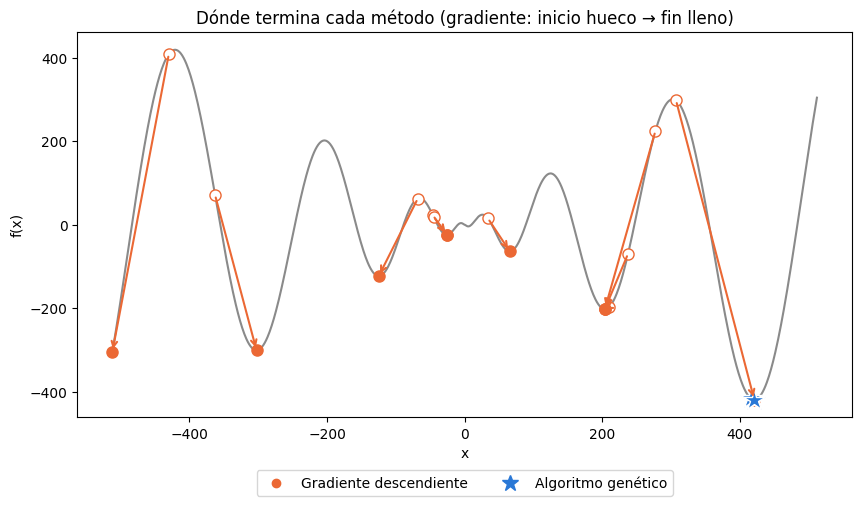

In [ ]:
tamañoPoblacion = 20
aptitudRequerida = 418.98
corridas = 10

#algoritmo genetico: 10 corridas
#reemplazo es el % de la poblacion que se va a reemplazar. 1: reemplazo generacional, <1 reemplazo elitista
resultados_ag = []
for corrida in range(corridas):
    random.seed(corrida)
    poblacion = []
    for i in range(tamañoPoblacion):
        poblacion.append(random.uniform(-512, 512))

    mejor, mejorAptitud, historia = algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo = 0.9, actividad = 1)
    resultados_ag.append((mejor, -mejorAptitud))   #f = -aptitud

#gradiente descendiente desde 10 puntos al azar
random.seed(100)
resultados_gd = []
for corrida in range(corridas):
    inicio = [random.uniform(-512, 512)]
    resultados_gd.append(gradiente_descendiente(inicio, 1, tasa = 1))

display(comparar(resultados_ag, resultados_gd, f_optimo = -418.98))
graficar_comparacion(1, resultados_ag, resultados_gd)

**Inciso 2**: $f(x, y) = (x^2 + y^2)^{0.25} \left[\sin^2\left(50(x^2+y^2)^{0.1}\right) + 1\right], \quad -100 \leq x, y \leq 100$

Generaciones: 200 - mejor aptitud: -0.03142211312052671
Generaciones: 200 - mejor aptitud: -0.01995971031682125
Generaciones: 200 - mejor aptitud: -0.01995971031682125


Generaciones: 200 - mejor aptitud: -0.01995971031682125
Generaciones: 200 - mejor aptitud: -0.01995971031682125
Generaciones: 200 - mejor aptitud: -0.03142211312052671
Generaciones: 200 - mejor aptitud: -0.01995971031682125


Generaciones: 200 - mejor aptitud: -0.01995971031682125
Generaciones: 200 - mejor aptitud: -0.01995971031682125
Generaciones: 200 - mejor aptitud: -0.054974566524833686


,mejor f,f promedio,llegó al mínimo global
Algoritmo genético,0.019960,0.025754,10/10
Gradiente descendiente,7.170735,8.794497,0/10


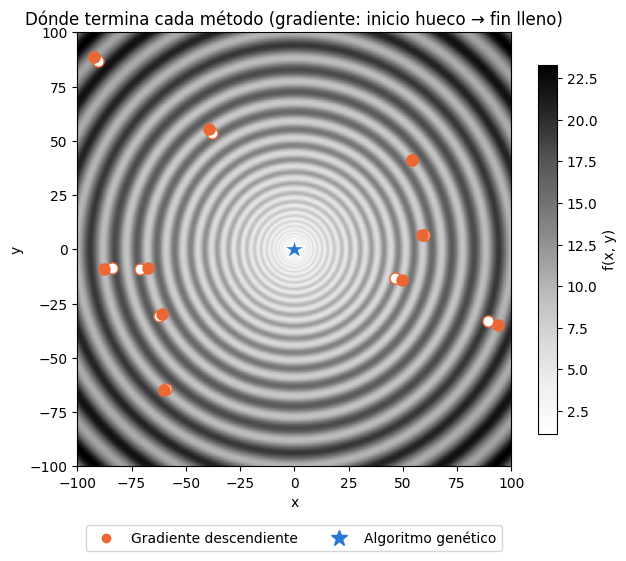

In [ ]:
tamañoPoblacion = 20
aptitudRequerida = 0

resultados_ag = []
for corrida in range(corridas):
    random.seed(corrida)
    poblacion = []
    for i in range(tamañoPoblacion):
        x = random.uniform(-100, 100)
        y = random.uniform(-100, 100)
        poblacion.append((x, y))

    mejor, mejorAptitud, historia = algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo = 0.9, actividad = 2)
    resultados_ag.append((mejor, -mejorAptitud))

random.seed(100)
resultados_gd = []
for corrida in range(corridas):
    inicio = [random.uniform(-100, 100), random.uniform(-100, 100)]
    resultados_gd.append(gradiente_descendiente(inicio, 2, tasa = 0.1))

display(comparar(resultados_ag, resultados_gd, f_optimo = 0))
graficar_comparacion(2, resultados_ag, resultados_gd)

**Conclusión:** el gradiente descendiente cae en el mínimo local más cercano al punto de partida, así que solo llega al global si arranca cerca. El algoritmo genético explora todo el dominio con la población y llega al mínimo global en casi todas las corridas (9/10 en el inciso 1, 10/10 en el inciso 2).

## Ejercicio 2

Diseñe e implemente un algoritmo genético que busque el mejor subconjunto de características para la clasificación de cáncer (leucemia linfocítica aguda y leucemia mielógena aguda) a partir de datos genómicos. Se proveen 38 muestras en el conjunto de entrenamiento y 34 en el conjunto de prueba (`leukemia_train.csv` y `leukemia_test.csv`, respectivamente). Cada muestra se compone de un total de 7129 características, que corresponden a valores de expresión génica.

### Idea

Cada paciente tiene **7129 genes** (columnas) y una clase (ALL o AML). Buscamos el **subconjunto de genes** que mejor separa las dos clases.

- **Individuo = máscara binaria**, un bit por gen: `1` uso el gen, `0` lo descarto. Por ejemplo, `11001` selecciona los genes 1, 2 y 5.
- **Aptitud**: aplico la máscara, entreno un clasificador **LVQ** solo con esos genes y mido qué tan bien clasifica pacientes que no usó para entrenar.

```mermaid
flowchart LR
    A["Individuo<br/>(máscara)"] --> B["Genes<br/>seleccionados"]
    B --> C["Entrenar LVQ"]
    C --> D["Clasificar<br/>validación"]
    D --> E["Aptitud"]
```

**LVQ** (*Learning Vector Quantization*) es un clasificador supervisado con un prototipo por clase. Para cada patrón de entrenamiento busca el prototipo más cercano: si es de la misma clase lo acerca al patrón, si no lo aleja. Para clasificar, cada paciente recibe la clase del prototipo más cercano.

**Respuestas a las dudas de la primera versión:**

- *¿Está bien interpretado el ejercicio?* Sí. Es exactamente el esquema de selección de características con AG de la cátedra (*wrapper*): cromosoma binario, un bit por característica, y un clasificador que da la aptitud.
- *¿LVQ se parece a K-medias?* Sí: los dos trabajan con prototipos y distancias. La diferencia es que K-medias es no supervisado (no conoce las clases) y LVQ usa las etiquetas para acercar o alejar los prototipos.
- *¿Con qué datos se mide la aptitud?* **No con test.** Si el AG elige los genes que mejor clasifican test, después no hay datos independientes para medir el resultado y queda inflado. La aptitud se mide en una parte de train (validación) y test se usa una sola vez, al final.

### Correcciones a la primera versión

- **Los CSV no tienen encabezado**: sin `header=None`, pandas usaba el primer paciente como nombres de columna y se perdía (quedaban 37 y 33 pacientes).
- **La aptitud ya no usa test**: train se separa en entrenamiento y validación, y la aptitud es el resultado en validación. Test se usa una sola vez al final (si no, el resultado queda inflado).
- **UAR** en vez de accuracy, porque las clases están desbalanceadas (27 ALL / 11 AML).
- **Normalización** de cada gen con media y desvío de train (los rangos van de 21 a 12 500).
- **LVQ sin azar**: los prototipos arrancan en el promedio de cada clase, así el mismo individuo siempre tiene la misma aptitud.
- **Subconjuntos chicos**: la población arranca con unos 10 genes por individuo (no la mitad), la mutación es 1/7129 por bit y la aptitud penaliza la cantidad de genes: $\text{UAR} - \beta \frac{\#\text{genes}}{7129}$.
- **Máximo de generaciones** para que siempre termine.

In [ ]:
#los csv no tienen encabezado
train = pd.read_csv("leukemia_train.csv", header=None)
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1].astype(int)

test = pd.read_csv("leukemia_test.csv", header=None)
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1].astype(int)

#normalizo cada gen con la media y el desvio de train
media = X_train.mean()
desvio = X_train.std()
X_train = (X_train - media) / desvio
X_test = (X_test - media) / desvio

#separo train en entrenamiento (2/3) y validacion (1/3), respetando la proporcion de cada clase
indices_val = []
for clase in [0, 1]:
    indices_clase = list(y_train[y_train == clase].index)
    for i in range(0, len(indices_clase), 3):
        indices_val.append(indices_clase[i])

X_val = X_train.loc[indices_val]
y_val = y_train.loc[indices_val]
X_ent = X_train.drop(indices_val)
y_ent = y_train.drop(indices_val)

print("entrenamiento:", len(X_ent), "- validacion:", len(X_val), "- test:", len(X_test), "- genes:", X_train.shape[1])

entrenamiento: 25 - validacion: 13 - test: 34 - genes: 7129


In [ ]:
#funcion que aplica la mascara a cada gen
def aplicar_mascara(individuo, X):
    columnas = []

    for i in range(len(individuo)):
        if individuo[i] == '1':
            columnas.append(i)

    return X.iloc[:, columnas]

#calculo la distancia entre el prototipo y el patron entrante, necesario para entrenar el LVQ
def distancia(a, b):
    suma = 0

    for i in range(len(a)):
        suma = suma + (a[i] - b[i]) ** 2

    return math.sqrt(suma)

#entrenamiento del clasificador
def entrenar_lvq(x, y, epocas = 20, tasa = 0.1):

    x = x.values
    y = y.values

    prototipos = []
    clases = [0, 1]

    #cada prototipo arranca en el promedio de su clase (sin azar)
    for clase in clases:
        indices = []
        for i in range(len(y)):
            if y[i] == clase:
                indices.append(i)

        prototipos.append(x[indices].mean(axis=0))

    # Entrenamiento
    for epoca in range(epocas):

        for i in range(len(x)):
            patron = x[i]
            clase = y[i]
            distancias = []
            for j in range(len(prototipos)):

                d = distancia(patron, prototipos[j])
                distancias.append(d)

            indice_ganador = distancias.index(min(distancias))

            #si pertenece a la clase, lo acerco
            if clases[indice_ganador] == clase:
                prototipos[indice_ganador] = prototipos[indice_ganador] + tasa * (patron - prototipos[indice_ganador])
            #si no pertenece, lo alejo
            else:
                prototipos[indice_ganador] = prototipos[indice_ganador] - tasa * (patron - prototipos[indice_ganador])

        tasa = tasa * 0.95

    return prototipos, clases

#funcion para testear mi clasificador
def predecir_lvq(x, prototipos, clases):

    x = x.values

    predicciones = []
    for muestra in x:
        distancias = []
        for prototipo in prototipos:
            d = distancia(muestra, prototipo)
            distancias.append(d)

        indice_ganador = distancias.index(min(distancias))

        predicciones.append(clases[indice_ganador])

    return predicciones

#UAR: promedio del porcentaje de aciertos de cada clase
def uar(reales, predicciones):
    suma = 0
    for clase in [0, 1]:
        total = 0
        aciertos = 0
        for i in range(len(reales)):
            if reales[i] == clase:
                total = total + 1
                if predicciones[i] == clase:
                    aciertos = aciertos + 1
        suma = suma + aciertos / total
    return suma / 2

#aptitud de un individuo (actividad 3): entreno LVQ con entrenamiento y mido UAR en validacion,
#menos una penalizacion por la cantidad de genes usados
BETA = 1
def aptitud_genes(individuo):
    cantidad = individuo.count('1')
    if cantidad == 0:
        return 0

    prototipos, clases = entrenar_lvq(aplicar_mascara(individuo, X_ent), y_ent)
    predicciones = predecir_lvq(aplicar_mascara(individuo, X_val), prototipos, clases)
    return uar(y_val.values, predicciones) - BETA * cantidad / len(individuo)

In [ ]:
tamañoPoblacion = 20
aptitudRequerida = 1   #no se alcanza por la penalizacion: corta por max_generaciones
cantidadGenes = X_train.shape[1]
corridas = 3

mejores = []
historias = []
for corrida in range(corridas):
    random.seed(corrida)
    poblacion = []
    for i in range(tamañoPoblacion):
        individuo = []

        #cada gen arranca prendido con probabilidad 10/7129: unos 10 genes por individuo
        for j in range(cantidadGenes):
            if random.random() < 10 / cantidadGenes:
                individuo.append('1')
            else:
                individuo.append('0')

        individuo = ''.join(individuo)
        poblacion.append(individuo)

    mejor, mejorAptitud, historia = algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo = 0.9,
                                                        actividad = 3, max_generaciones = 100)
    mejores.append(mejor)
    historias.append(historia)

Generaciones: 100 - mejor aptitud: 0.9990180951045028


Generaciones: 100 - mejor aptitud: 0.99845700659279


Generaciones: 100 - mejor aptitud: 0.9988778229765746


,,genes,cantidad,UAR test
0,Todos los genes,-,7129,0.750000
1,AG corrida 0,"[40, 402, 993, 1973, 2173, 2607, 3185]",7,0.442857
2,AG corrida 1,"[1528, 2378, 2407, 2422, 3062, 3632, 3773, 383...",11,0.650000
3,AG corrida 2,"[61, 1742, 1979, 3871, 4434, 4774, 6214, 6733]",8,0.725000


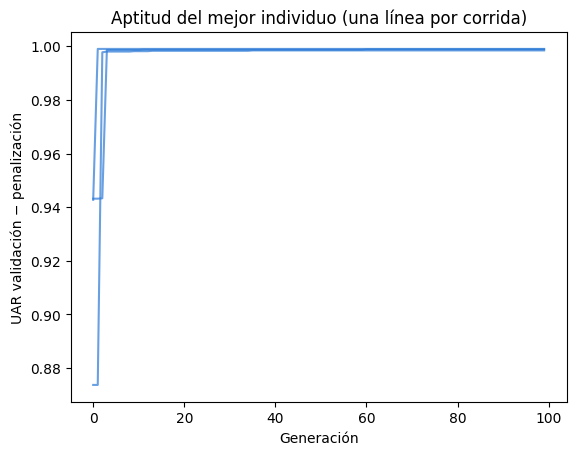

In [ ]:
#evaluacion final: entreno LVQ con TODO train usando los genes elegidos y mido en test (que nunca se uso)
def uar_test(individuo):
    prototipos, clases = entrenar_lvq(aplicar_mascara(individuo, X_train), y_train)
    predicciones = predecir_lvq(aplicar_mascara(individuo, X_test), prototipos, clases)
    return uar(y_test.values, predicciones)

filas = []
todos = '1' * cantidadGenes
filas.append(["Todos los genes", "-", cantidadGenes, uar_test(todos)])
for corrida in range(corridas):
    genes = []
    for i in range(cantidadGenes):
        if mejores[corrida][i] == '1':
            genes.append(i)
    filas.append(["AG corrida " + str(corrida), genes, len(genes), uar_test(mejores[corrida])])

display(pd.DataFrame(filas, columns=["", "genes", "cantidad", "UAR test"]))

#evolucion de la aptitud del mejor individuo
for historia in historias:
    plt.plot(historia, color=AZUL, alpha=0.7)
plt.xlabel("Generación")
plt.ylabel("UAR validación − penalización")
plt.title("Aptitud del mejor individuo (una línea por corrida)")
plt.show()

**Conclusión:** el AG reduce de 7129 a unos 7–11 genes con aptitud casi perfecta en validación, pero en test le va peor que usar todos los genes. Es **sobreajuste a la validación**: con solo 13 pacientes de validación y 7129 genes, hay muchas combinaciones chicas que los clasifican bien por casualidad. Medir en test sin haberlo usado durante la búsqueda es lo que permite verlo. Una forma de reducirlo es que el AG busque solo entre los genes que individualmente mejor separan las clases (prefiltro por señal/ruido), como se hace en `TP6-2.ipynb`.